In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as fy

In [2]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 8.3 MB/s eta 0:00:01
   ------------------------------------- -- 1.6/1.7 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.2 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=54ad727283fee1fc35eb8efde176f91de9ad8ecb5f766219fce75ad892857025
  Stored in directory: c:\users\arghadeep\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5

In [12]:
pip install yfinance --upgrade

Note: you may need to restart the kernel to use updated packages.


=========== Complete Stock Analyser =============


Enter the stock symbol(Add '.NS' in case of Indian Stocks) (or Q to Quit): GOOG



Company name : Alphabet Inc.
Current price: 336.5USD
 Change : +6.03 (+1.82%)



[*********************100%***********************]  1 of 1 completed


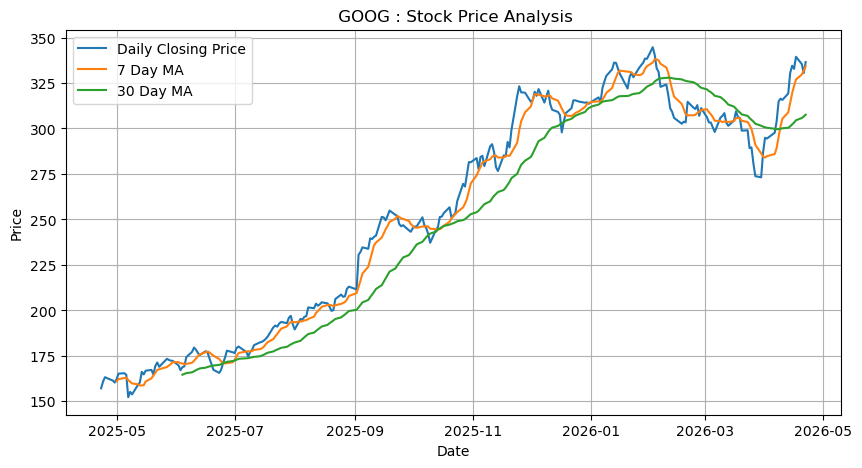

Enter the stock symbol(Add '.NS' in case of Indian Stocks) (or Q to Quit): META



Company name : Meta Platforms, Inc.
Current price: 675.545USD
 Change : +6.70 (+1.00%)



[*********************100%***********************]  1 of 1 completed


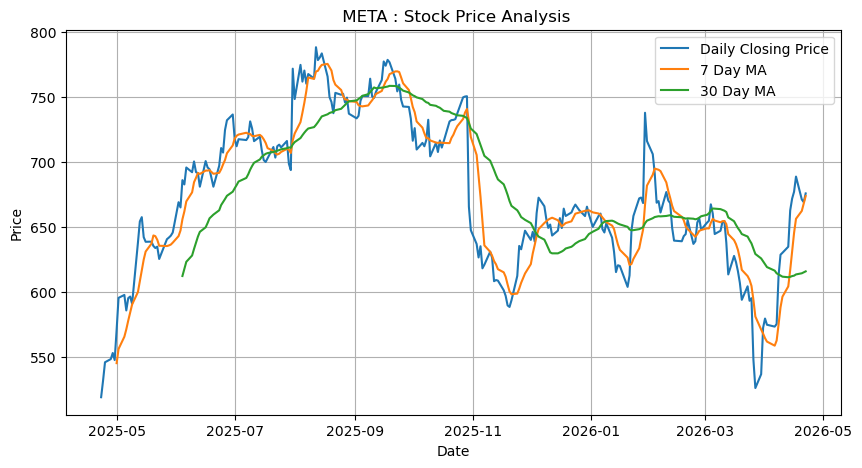

Enter the stock symbol(Add '.NS' in case of Indian Stocks) (or Q to Quit): NVDA



Company name : NVIDIA Corporation
Current price: 201.815USD
 Change : +1.94 (+0.97%)



[*********************100%***********************]  1 of 1 completed


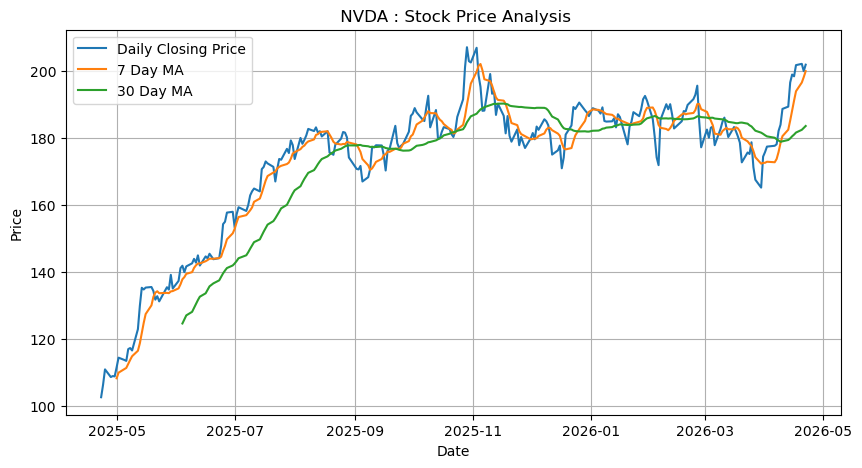

Enter the stock symbol(Add '.NS' in case of Indian Stocks) (or Q to Quit): q


Thank you for using.See you again


In [30]:
print("=========== Complete Stock Analyser =============")

while True:
    
    symbol = input("Enter the stock symbol(Add '.NS' in case of Indian Stocks) (or Q to Quit):").upper()
    if symbol == "Q":
        print("Thank you for using.See you again")
        break

    
    

    try:
        stock = fy.Ticker(symbol)
        info = stock.info

        name = info.get("longName","N/A")
        price = info.get("currentPrice")
        prev_price = info.get("previousClose")
        currency = info.get("currency")

        if currency is None:
            if symbol.endswith(".NS"):
                currency="₹"
            else:
                currency="$"
        
        print("\n==========================")
        print(f"Company name : {name}")
        print(f"Current price: {price}{currency}")
        
        if price and prev_price:
            change = price - prev_price
            percent = (change/prev_price)*100
            print(f" Change : {change:+.2f} ({percent:+.2f}%)")
        
        print("\n==========================")


        df = fy.download(symbol, start = "2025-04-23", end = "2026-04-23", interval = "1d")

        df["7_day_MA"] = df["Close"].rolling(window=7).mean()        
        df["30_day_MA"] = df["Close"].rolling(window=30).mean()


        plt.figure(figsize=(10,5))
        plt.plot(df["Close"],label="Daily Closing Price")
        plt.plot(df["7_day_MA"],label="7 Day MA")   # MA = moving average
        plt.plot(df["30_day_MA"],label="30 Day MA")
        plt.title(f" {symbol} : Stock Price Analysis")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True)
        plt.show()

    
    
    except Exception as e:
        print("Invalid Symbol or Network Error\n")
      